In [ ]:
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable GPU temporarily to reconfigure
gpus = tf.config.list_physical_devices('GPU')


import pandas as pd
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import librosa
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
import numpy as np
from utils import apply_bandpass_filter, get_optimizer, get_class_weights, get_monitor, plot_confusion_matrix, plot_training_history, encode_labels
import librosa

LOWCUT, HIGHCUT = 20, 500   
SEGMENT_EXTENSION_MS = 3

data = "./features-relative.csv"

df = pd.read_csv(data)

filtered_signals = {} 

df["file"] = df["file"].apply(lambda p: p.replace("\\", "/"))

for file_path in df["file"].unique():
    signal, fs = librosa.load(file_path)
    
    signal_filtered = apply_bandpass_filter(signal, fs)
    filtered_signals[file_path] = (signal_filtered, fs)

2025-12-11 14:30:57.914286: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-11 14:30:57.984392: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:

df["segment"] = None

for index, row in df.iterrows():
    file_path = row["file"]
    file_path = file_path.replace('\\', '/')
    signal_filtered, fs = filtered_signals[file_path]
    
    start_sample = row["Start"]
    end_sample = row["End"]
    
    start_sample = int(start_sample * fs)
    end_sample = int(end_sample * fs)
    extension_samples = int((SEGMENT_EXTENSION_MS / 1000) * fs)
    
    extended_start = max(0, start_sample - extension_samples)
    extended_end = min(len(signal_filtered), end_sample + extension_samples)
    
    segment = signal_filtered[extended_start:extended_end]
    df.at[index, "segment"] = segment


max_len = max(len(segment) for segment in df["segment"]) 

def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

features = []

segments = np.array([pad_segment(seg, max_len) for seg in df["segment"]])
features.append(segments)

X = np.stack(features, axis=-1)
print("X shape:", X.shape)  
print("Feature channels:", len(features))

def remap_label(label):
    label_lower = str(label).strip().lower()
    if label_lower in ['psw', 'fibrillation']:
        return 'positive'
    elif label_lower == "nan":
        return 'none'
    else:
        return str(label)  
    
def labels_to_string(label):
    label_lower = str(label).strip().lower()
    if label_lower == "nan":
        return 'none'
    else:
        return str(label)

df['Label_Remapped'] = df['Label'].apply(labels_to_string)
y = df['Label_Remapped']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

y_train, y_test = encode_labels(y_train, y_test)


X shape: (3514, 980, 1)
Feature channels: 1
{'Fibrillation': np.int64(475), 'PSW': np.int64(1849), 'none': np.int64(1190)}

Label distribution:
Label_Remapped
PSW             1849
none            1190
Fibrillation     475
Name: count, dtype: int64
{np.int64(0): np.int64(475), np.int64(1): np.int64(1849), np.int64(2): np.int64(1190)}

Encoded labels: ['Fibrillation' 'PSW' 'none']

Training samples: 2811, Test samples: 703
Segments extended by ±3ms and filtered globally (20-500 Hz)!


In [3]:


n_channels = X.shape[-1]

model = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(max_len, n_channels)),  
    MaxPooling1D(2),
    Conv1D(128, 5, activation='relu', padding='same'),
    MaxPooling1D(2),
    Conv1D(256, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

/home/joaquinm/EMG-Thesis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
from tensorflow import keras
from sklearn.utils import shuffle

model.compile(
    optimizer=get_optimizer(),  
    loss='sparse_categorical_crossentropy',  
    metrics=["accuracy"]
)
X_train, y_train = shuffle(X_train, y_train, random_state=42)
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_split=0.1,
                    callbacks=[get_monitor()],
                    class_weight=get_class_weights(y_train))

Epoch 1/100


2025-12-11 14:31:04.103227: I external/local_xla/xla/service/service.cc:163] XLA service 0x75482000e5c0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-12-11 14:31:04.103262: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-12-11 14:31:04.145032: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 1/80 ━━━━━━━━━━━━━━━━━━━━ 3:08 2s/step - accuracy: 0.1875 - loss: 1.1408

I0000 00:00:1765463464.844954  199016 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.5627 - loss: 1.0517 - val_accuracy: 0.6596 - val_loss: 0.9312
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.6481 - loss: 0.9115 - val_accuracy: 0.6773 - val_loss: 0.9037
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.6686 - loss: 0.8419 - val_accuracy: 0.6702 - val_loss: 0.8938
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6979 - loss: 0.7902 - val_accuracy: 0.6631 - val_loss: 0.9126
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.7110 - loss: 0.7444 - val_accuracy: 0.7482 - val_loss: 0.8033
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.7276 - loss: 0.6969 - val_accuracy: 0.7305 - val_loss: 0.8255
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7509 - loss: 0.6624 - val_accuracy: 0.7482 - val_loss: 0.7666
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7659 - loss: 0.6143 - val_accuracy: 0.6667 - val_l

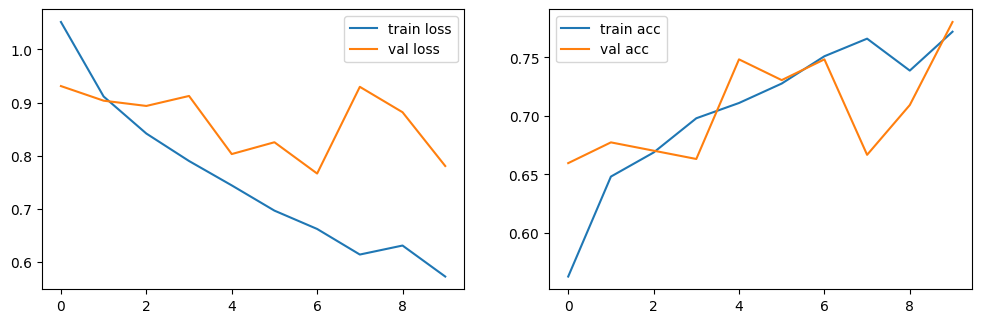

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


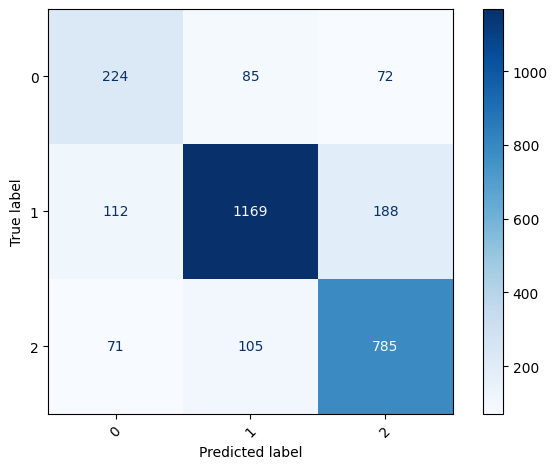

In [5]:
plot_training_history(history)

y_pred = model.predict(X_train)
y_pred_classes = np.argmax(y_pred, axis=1)

plot_confusion_matrix(y_train, y_pred_classes)